# Laptop Price Predition: Data Processing

In [1]:
# Import libraries for data analysis & visualisation
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import sys

In [2]:
# System configuration
sys.path.append(os.path.abspath(".."))

## Problem Statement

For this project, we have 800 laptops that have been placed across the E-Commerce market. These laptops have advanced specifications that determines their sale prices. These prices are expressed in Indian rupees ranging from 1k till 20k. However, we are interested about finding the best sale price that we propose for the buyer based on the specifications of the laptop he desires. This is the reason why machine learning involves in this problem which contains functionalities and algorithms for building a system that estimates the best price for a laptop. 

The aim of this project is to build a laptop price predictor system that focuses on making the best predictions on laptop prices that might satisfy the buyer's purchase expectations. We will be using 5 different models to measure its efficiency on performing the prediction task on the estimated price. These models are supervised models mainly focused on solving regression problem. We will be utilising models like linear regression, regression trees, advanced regression models(Ridge, Lasso and ElasticNet) and XGBoost Regression model from which we will conclude its efficiency and performance on making the best price predictions.

The dataset that will be handled throughout this project is from the Kaggle website. It contains 800 different laptops with their 19 specifications, including the price. In the context of supervised learning, the price will be considered as target although the rest of the specifications are input features that the user can specifiy. 

Source: https://www.kaggle.com/datasets/anubhavgoyal10/laptop-prices-dataset 

## Machine Learning Pipeline

This project follows a clear and simple Machine Learning Pipeline where some data engineering and model development techniques will be demonstrated. The pipeline is comprised of phases starting from loading the laptop price dataset until finishing the evaluation stage. Here is a clear pipeline that indicates the phases of the process: 

1. Data Collection
2. Exploratory Data Analysis
3. Data Preparation
4. Feature Engineering
4. Model Building
5. Model Training
6. Model Evaluation
7. Model Summary

The model summary, considered as the final stage of the workflow, encompasses all trained and evaluated models. It is an extended overview where each model shows its performance metrics and its accuracies. This will help us to draw a conclusion about which models is the best fit for making the best price predictions on those laptops. 

## Data Collection

In [3]:
# Implement functionalities
from scripts.data_collection import DataLoader

In [4]:
# Instantiate object from DataLoader
data_loader_obj = DataLoader("data")
laptop_ds = data_loader_obj.collect("laptopPrice.csv")
laptop_ds

,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
brand,,,,,,,,,,,,,,,,,,
ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ASUS,AMD,Ryzen 9,Not Available,4 GB,DDR4,1024 GB,0 GB,Windows,64-bit,0 GB,Casual,1 year,No,No,135990,3 stars,0,0
ASUS,AMD,Ryzen 9,Not Available,4 GB,DDR4,1024 GB,0 GB,Windows,64-bit,0 GB,Casual,1 year,No,No,144990,3 stars,0,0
ASUS,AMD,Ryzen 9,Not Available,4 GB,DDR4,1024 GB,0 GB,Windows,64-bit,4 GB,Casual,1 year,No,No,149990,3 stars,0,0


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a common data science method discover findings and learn patterns from datasets that enables us to generate meaningfull insights. For each phase, we will also discuss what meaningful findings we have located. 

EDA has multiple analysis techniques, but we will be considering those techniques to move forward throughout the project: 

1. Descriptive Analysis: understanding the construct of the dataset and its properties
2. Univariate Analysis: for numerical and categorical data
3. Multivariate Analysis: building correlation map only on numeric features

## Descriptive Analysis

In [5]:
# Find information about the laptop dataset
laptop_ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 823 entries, ASUS to Lenovo
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   processor_brand    823 non-null    object
 1   processor_name     823 non-null    object
 2   processor_gnrtn    823 non-null    object
 3   ram_gb             823 non-null    object
 4   ram_type           823 non-null    object
 5   ssd                823 non-null    object
 6   hdd                823 non-null    object
 7   os                 823 non-null    object
 8   os_bit             823 non-null    object
 9   graphic_card_gb    823 non-null    object
 10  weight             823 non-null    object
 11  warranty           823 non-null    object
 12  Touchscreen        823 non-null    object
 13  msoffice           823 non-null    object
 14  Price              823 non-null    int64 
 15  rating             823 non-null    object
 16  Number of Ratings  823 non-null    int64 
 

In [6]:
# Find number of duplicated rows
laptop_dupl = laptop_ds.duplicated().sum()
print(f"Number of duplicated records: {laptop_dupl}")

# Find number of nullvalues 
null_arr = laptop_ds.isnull().sum().values
tot_nullvals = np.sum(null_arr)
print(f"Total null values: {tot_nullvals}")

Number of duplicated records: 22
Total null values: 0


In [7]:
# Build a descriptive dataframe that includes features like: nullvalues, uniquevalues, datatypes
descr_df = pd.DataFrame()
descr_df["Properties"] = laptop_ds.columns
descr_df["Nullvlaues"] = laptop_ds.isnull().sum().values
descr_df["Uniquevalues"] = laptop_ds.nunique().values
descr_df["DataTypes"] = laptop_ds.dtypes.values

# Show descriptive dataset
descr_df.transpose()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
Properties,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
Nullvlaues,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Uniquevalues,3,11,8,4,6,7,4,3,2,5,3,4,2,2,405,5,282,135
DataTypes,object,object,object,object,object,object,object,object,object,object,object,object,object,object,int64,object,int64,int64


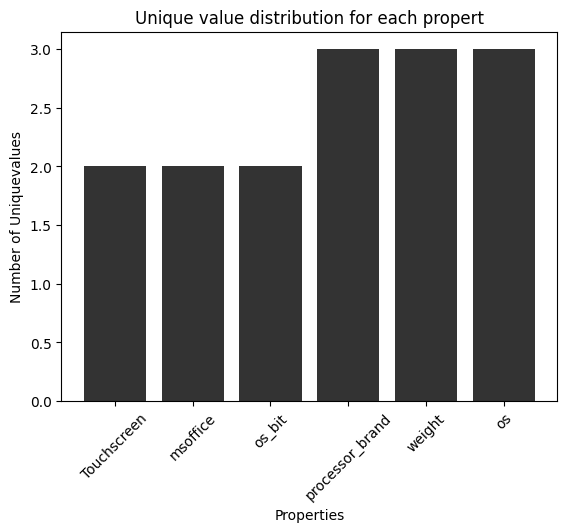

In [8]:
# Visualise the data distribution across top 5 features with the highest unique values 
descr_df_asc = descr_df.sort_values(by=["Uniquevalues"], ascending=True)
descr_df_asc.index = [i for i in range(descr_df.shape[0])]
descr_df_asc

# Implement function: graph a descriptive data distribution
def graph_descr_dist(indep_name: str, target_name: str, 
                     set_title: str):
    # Initialise indep and dep variables
    indep_var = descr_df_asc[indep_name].loc[:5].values 
    target_var = descr_df_asc[target_name].loc[:5].values 

    # Visualise data distribution using bar chart
    plt.bar(indep_var, target_var, color="black", alpha=0.80)
    plt.xlabel(indep_name)
    plt.ylabel(f"Number of {target_name}")
    plt.title(set_title)
    plt.xticks(rotation=45)

# Call method 
title = "Unique value distribution for each propert"
graph_descr_dist("Properties", "Uniquevalues", title)

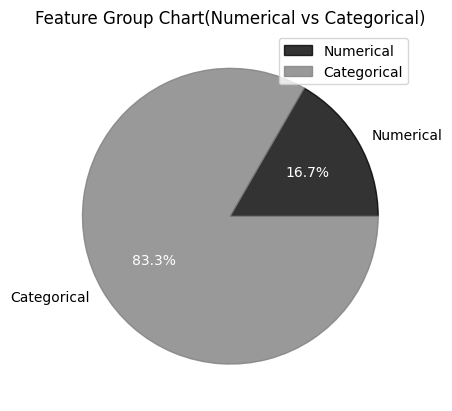

In [9]:
# Discover how many numerical variables and categorical variables the dataset contains
numerical_features = laptop_ds.select_dtypes([int, float]).columns
categoriical_features = laptop_ds.select_dtypes([object]).columns

feature_gr_size = [len(numerical_features), len(categoriical_features)]
feature_gr_labels = ["Numerical", "Categorical"]
colors = ["black", "grey"]
# opacities = [0.60, 0.60]

fig, ax = plt.subplots()
pies = ax.pie(feature_gr_size, labels=feature_gr_labels, autopct="%1.1f%%")

for pie, annot, color in zip(pies[0], pies[2], colors):
    # Change the pie layout
    pie.set_color(color)
    pie.set_alpha(0.80)

    # Change annotation
    annot.set_color("white")

plt.title("Feature Group Chart(Numerical vs Categorical)")
plt.legend()

**Descriptive Analysis: Insights**

From the descriptive analysis we discovered these findings: 
- the datasets contains 800 samples representing the 800 laptops with its specifications
- the specifications contain 15.8 % of features labeled as numerical although 84.2 % are categorical features 
- the datasets contains no null values, but has 21 duplicated rows. These duplicated records will be removed to overcome bios affect on the model performance

Suspecion: among the categorical feature group, there are features as RAM, Storage, etc. which are more likely to be considered as numericals without the suffixes. Therefore, the majority of features are falsely classified as objects. With data preprocessing, these features will be handled and processed in order to become numeric. 


## Univariate Analysis

In [10]:
# Import functionalities 
from collections import Counter

Univariate analysis helps us to gain insight about one single feature. The type of chart that we use is specifically based on the type of the feature we want to investigate. Categorical features can be easily used through barplots to visualise distinct independent categories. Numerical features can be visualised through histograms to identify the distrubtion of the data. 

**Univeriate Analysis: Categorical Features**

Text(0.5, 1.0, 'Feature Type Distribution (Multivariate vs Binary)')

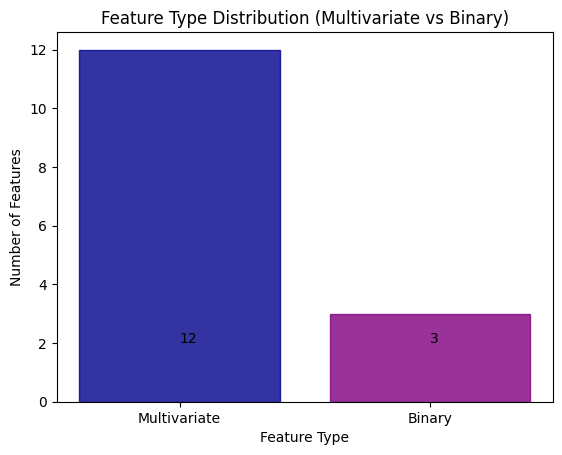

In [11]:
# Identify categorical features through bar plots 
laptop_cat_ds = laptop_ds.select_dtypes(object)
laptop_cat_ds

# Identify whether feature is binary or multivariate
category_df = pd.DataFrame()
categories = laptop_cat_ds.columns
category_df["Categorical Feature"] = categories
category_df["Unique Values"] = laptop_cat_ds.nunique().values
category_df["Feature Type"] = category_df["Unique Values"].apply(lambda x: "Binary" if x == 2 else "Multivariate")
category_df

# Visualise binary and multivariate features using bar plot
feature_types = category_df["Feature Type"].values

# Define a counter 
counter = Counter(feature_types)
ft_couple = {key:value for key, value in counter.items()}

fig, ax = plt.subplots()
bars = ax.bar(ft_couple.keys(), ft_couple.values())

for bar, color in zip(bars, ["darkblue", "purple"]):
    # Set bar color and its opacity
    bar.set_color(color)
    bar.set_alpha(0.8)

    # Set the value label (= bar height) for each bar
    height = bar.get_height()
    xpos, ypos = bar.get_x(), bar.get_y()
    plt.text(xpos +0.4, ypos+2, height)

plt.xlabel("Feature Type")
plt.ylabel("Number of Features")
plt.title("Feature Type Distribution (Multivariate vs Binary)")

In [12]:
# Identify features that are multivariate and binary 
multi_features = category_df[category_df["Feature Type"] == "Multivariate"]["Categorical Feature"].values
binary_features = category_df[category_df["Feature Type"] == "Binary"]["Categorical Feature"].values

print(f"Binary Features: {binary_features}")
print(f"Multivariate Features: {multi_features}")

Binary Features: ['os_bit' 'Touchscreen' 'msoffice']
Multivariate Features: ['processor_brand' 'processor_name' 'processor_gnrtn' 'ram_gb' 'ram_type'
 'ssd' 'hdd' 'os' 'graphic_card_gb' 'weight' 'warranty' 'rating']


In [13]:
# Identify these features 
laptop_ds[multi_features]
laptop_ds[binary_features]

,os_bit,Touchscreen,msoffice
brand,,,
ASUS,64-bit,No,No
Lenovo,64-bit,No,No
Lenovo,64-bit,No,No
ASUS,32-bit,No,No
ASUS,64-bit,No,No
...,...,...,...
ASUS,64-bit,No,No
ASUS,64-bit,No,No
ASUS,64-bit,No,No


Multivariate feature group containing the features ram_gb, ssd, hdd, graphic_card_gb and rating are obviously numerical features. These features need to be preprocessed and converted to numerical types. 

In [14]:
# Features that should be considered as numerical features
numeric_like_features = ['ram_gb','ssd', 'hdd', 'graphic_card_gb', 'rating']
laptop_ds[numeric_like_features]

,ram_gb,ssd,hdd,graphic_card_gb,rating
brand,,,,,
ASUS,4 GB,0 GB,1024 GB,0 GB,2 stars
Lenovo,4 GB,0 GB,1024 GB,0 GB,3 stars
Lenovo,4 GB,0 GB,1024 GB,0 GB,3 stars
ASUS,8 GB,512 GB,0 GB,2 GB,3 stars
ASUS,4 GB,0 GB,512 GB,0 GB,3 stars
...,...,...,...,...,...
ASUS,4 GB,1024 GB,0 GB,0 GB,3 stars
ASUS,4 GB,1024 GB,0 GB,0 GB,3 stars
ASUS,4 GB,1024 GB,0 GB,4 GB,3 stars


Without considering to numerical like features, we discover the findings from categorical features

In [15]:
# Identify meaningful insights from categorical features 
categoriical_features = [feature for feature in categoriical_features]
for non_cat_f in numeric_like_features: 
    categoriical_features.remove(non_cat_f)

print(f"New Categorical features(without num like features): {categoriical_features}")

New Categorical features(without num like features): ['processor_brand', 'processor_name', 'processor_gnrtn', 'ram_type', 'os', 'os_bit', 'weight', 'warranty', 'Touchscreen', 'msoffice']


## Data Preparation

The data preparation stage mainly focuses on cleaning data by removing nullvalues, inconsistencies and irrelevant data. As we do not face null values in the dataset, we might focous on finding inconsistent data and converting some features to its proper datatype. These are the steps we will take

1. Removing duplicated rows
2. Inconsistent Removal
3. Feature Conversion: removing suffixes and conver to numerical features  

**1. Removing duplicated rows**

In [16]:
# Identiy number of duplicated rows
num_dupl_rows = laptop_ds.duplicated().sum()
print(f"Number of duplicated rows (before removal): {num_dupl_rows}")

# Remove duplicated rows 
laptop_ds = laptop_ds.drop_duplicates()
print("Removing duplicates successful !")

Number of duplicated rows (before removal): 22
Removing duplicates successful !


In [17]:
# Identify number of duplicated rows after removal
num_dupl_rows = laptop_ds.duplicated().sum()
print(f"Number of duplicated rows (after removal): {num_dupl_rows}")

Number of duplicated rows (after removal): 0


**2. Nullvalue Analysis & Removal**

In [18]:
# Check null values 
null_df = pd.DataFrame()
null_df["Nullvalues"] = laptop_ds.isnull().sum().values
null_df["Features"] = laptop_ds.columns.values

# Show null values 
null_df.transpose()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
Nullvalues,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Features,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews


In [19]:
# Remove null values on warranty 
laptop_ds.loc[:, "warranty"] = laptop_ds["warranty"].fillna("No warranty")

**2. Inconsistent Analysis & Removal**

In [20]:
# Identify feature data with inconsistencies
suffixes = ["GB", "stars", "star", "bit", "warranty"]
incon_features = []

for feature in laptop_ds.columns:
    # Extract feature value
    feature_data = laptop_ds[feature].astype(str)
    feature_arr = feature_data.values
    feature_value = feature_arr[0]
    
    for s in suffixes:
        # Check if suffixes are available in these strings
        if s in feature_value:
            incon_feature = feature
            incon_features.append(incon_feature)
    
# Create an inconsistent dataset
seen = set()
incon_features = [f for f in incon_features if not (f in seen or seen.add(f))]
incon_df = laptop_ds[incon_features]
incon_df

,ram_gb,ssd,hdd,os_bit,graphic_card_gb,warranty,rating
brand,,,,,,,
ASUS,4 GB,0 GB,1024 GB,64-bit,0 GB,No warranty,2 stars
Lenovo,4 GB,0 GB,1024 GB,64-bit,0 GB,No warranty,3 stars
Lenovo,4 GB,0 GB,1024 GB,64-bit,0 GB,No warranty,3 stars
ASUS,8 GB,512 GB,0 GB,32-bit,2 GB,No warranty,3 stars
ASUS,4 GB,0 GB,512 GB,64-bit,0 GB,No warranty,3 stars
...,...,...,...,...,...,...,...
ASUS,4 GB,1024 GB,0 GB,64-bit,0 GB,1 year,3 stars
ASUS,4 GB,1024 GB,0 GB,64-bit,0 GB,1 year,3 stars
ASUS,4 GB,1024 GB,0 GB,64-bit,4 GB,1 year,3 stars


In [21]:
# Remove suffix 1: GB
laptop_ds.loc[:,"ram_gb"] = incon_df["ram_gb"].str.replace("GB", "")
laptop_ds.loc[:,"ssd"] = incon_df["ssd"].str.replace("GB", "")
laptop_ds.loc[:,"hdd"] = incon_df["hdd"].str.replace("GB", "")
laptop_ds.loc[:,"graphic_card_gb"] = incon_df["graphic_card_gb"].str.replace("GB", "")

# Remove suffix 2: bit
laptop_ds.loc[:,"os_bit"] = incon_df["os_bit"].str.replace("-bit", "")

# Remove suffix 3: stars and star
laptop_ds.loc[:,"rating"] = incon_df["rating"].str.extract(r"(\d)", expand=False)

# Remove suffix 4: warranty
laptop_ds.loc[:, "warranty"] = incon_df["warranty"].str.replace("No warranty", "0 years")
laptop_ds.loc[:, "warranty"] = laptop_ds["warranty"].str.split(" ", expand=True)[0]

In [22]:
# Set inconsistent features into numeric type 
laptop_ds.loc[:, "ssd"] = laptop_ds["ssd"].astype(int)
laptop_ds.loc[:,"hdd"] = laptop_ds["hdd"].astype(int)
laptop_ds.loc[:, "ram_gb"] = laptop_ds["ram_gb"].astype(int)
laptop_ds.loc[:, "graphic_card_gb"] = laptop_ds["graphic_card_gb"].astype(int)
laptop_ds.loc[:, "os_bit"] = laptop_ds["os_bit"].astype(int)
laptop_ds.loc[:, "warranty"] = laptop_ds["warranty"].astype(int)

In [23]:
# Check new dataset
# Compute the mode of the series
mode_comp = lambda feature: laptop_ds[feature].mode().loc[0]

# Replace zeros by its mode
laptop_ds.loc[:, "ssd"] = laptop_ds["ssd"].apply(lambda x: mode_comp("ssd") if x == 0 else x)
laptop_ds.loc[:, "ram_gb"] = laptop_ds["ram_gb"].apply(lambda x: mode_comp("ram_gb") if x == 0 else x)
# laptop_ds.loc[:, "hdd"] = laptop_ds["hdd"].apply(lambda x: mode_comp("hdd") if x == 0 else x)
laptop_ds.loc[:, "warranty"] = laptop_ds["warranty"].apply(lambda x: mode_comp("warranty") if x == 0 else x)
laptop_ds.loc[:, "os_bit"] = laptop_ds["os_bit"].apply(lambda x: mode_comp("os_bit") if x == 0 else x)
laptop_ds.loc[:, "graphic_card_gb"] = laptop_ds["graphic_card_gb"].apply(lambda x: mode_comp("graphic_card_gb") if x == 0 else x)
laptop_ds.loc[:, "rating"] = laptop_ds["rating"].apply(lambda x: mode_comp("ratings") if x == 0 else x)


In [24]:
laptop_ds["hdd"].value_counts()

hdd
0       601
1024    159
512      40
2048      1
Name: count, dtype: int64

In [25]:
# Reset the index
laptop_ds = laptop_ds.reset_index()

# Rename the feature names
feature_names = laptop_ds.columns
laptop_ds.columns = [feature.capitalize() for feature in feature_names]
laptop_ds

,Brand,Processor_brand,Processor_name,Processor_gnrtn,Ram_gb,Ram_type,Ssd,Hdd,Os,Os_bit,Graphic_card_gb,Weight,Warranty,Touchscreen,Msoffice,Price,Rating,Number of ratings,Number of reviews
0,ASUS,Intel,Core i3,10th,4,DDR4,512,1024,Windows,64,0,Casual,1,No,No,34649,2,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,512,1024,Windows,64,0,Casual,1,No,No,38999,3,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,512,1024,Windows,64,0,Casual,1,No,No,39999,3,8,1
3,ASUS,Intel,Core i5,10th,8,DDR4,512,0,Windows,32,2,Casual,1,No,No,69990,3,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4,DDR4,512,512,Windows,64,0,Casual,1,No,No,26990,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,ASUS,AMD,Ryzen 9,Not Available,4,DDR4,1024,0,Windows,64,0,Casual,1,No,No,135990,3,0,0
797,ASUS,AMD,Ryzen 9,Not Available,4,DDR4,1024,0,Windows,64,0,Casual,1,No,No,144990,3,0,0
798,ASUS,AMD,Ryzen 9,Not Available,4,DDR4,1024,0,Windows,64,4,Casual,1,No,No,149990,3,0,0
799,ASUS,AMD,Ryzen 9,Not Available,4,DDR4,1024,0,Windows,64,4,Casual,1,No,No,142990,3,0,0


## Data Storage

In [26]:
# Store the dataset
data_loader_obj.save(("laptop_price_dataset", laptop_ds), "processed", 2)

## Conclusion

Data has been analysed, cleaned and processed. The new processed dataset will be considered for further processes, like feature engineering, model training and validation. 

Created by A. Mian on 08/04/2026